<a href="https://colab.research.google.com/github/Deepak-T09/ML-Project/blob/main/PA_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho")

Skipping, found downloaded files in "./vehicle-dataset-from-cardekho" (use force=True to force download)


In [24]:
import os
for dirname, _, filenames in os.walk('./vehicle-dataset-from-cardekho'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./vehicle-dataset-from-cardekho/car data.csv
./vehicle-dataset-from-cardekho/Car details v3.csv
./vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv
./vehicle-dataset-from-cardekho/car details v4.csv


In [25]:
df = pd.read_csv('./vehicle-dataset-from-cardekho/car data.csv')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [27]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [28]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [29]:
df["Owner"].unique()

array([0, 1, 3])

In [30]:
df["Fuel_Type"].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [31]:
df["Seller_Type"].unique()

array(['Dealer', 'Individual'], dtype=object)

In [32]:
df["Transmission"].unique()

array(['Manual', 'Automatic'], dtype=object)

In [33]:
import numpy as np
df["Seller_Type_Id"]=np.where(df["Seller_Type"].str.contains("Dealer"),0,1)

In [34]:
df["Seller_Type_Id"].unique()

array([0, 1])

In [35]:
df["Transmission_Id"]=np.where(df["Transmission"].str.contains("Manual"),0,1)

In [36]:
df["Transmission_Id"].unique()

array([0, 1])

In [37]:
df["Fuel_Type_Id"]=df["Fuel_Type"].map({
    'Petrol':0,
    'Diesel':1,
    'CNG':2
    })

In [38]:
df["Fuel_Type_Id"].unique()

array([0, 1, 2])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Car_Name         301 non-null    object 
 1   Year             301 non-null    int64  
 2   Selling_Price    301 non-null    float64
 3   Present_Price    301 non-null    float64
 4   Kms_Driven       301 non-null    int64  
 5   Fuel_Type        301 non-null    object 
 6   Seller_Type      301 non-null    object 
 7   Transmission     301 non-null    object 
 8   Owner            301 non-null    int64  
 9   Seller_Type_Id   301 non-null    int64  
 10  Transmission_Id  301 non-null    int64  
 11  Fuel_Type_Id     301 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 28.3+ KB


In [40]:
df_1=df.drop(["Fuel_Type","Seller_Type","Transmission"],axis=1)

In [41]:
df_1.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Seller_Type_Id,Transmission_Id,Fuel_Type_Id
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189,0.352159,0.132890,0.212625
std,2.891554,5.082812,8.644115,38886.883882,0.247915,0.478439,0.340021,0.425801
min,2003.000000,0.100000,0.320000,500.000000,0.000000,0.000000,0.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000,0.000000,0.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000,0.000000,0.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000,1.000000,0.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000,1.000000,1.000000,2.000000


In [42]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Car_Name         301 non-null    object 
 1   Year             301 non-null    int64  
 2   Selling_Price    301 non-null    float64
 3   Present_Price    301 non-null    float64
 4   Kms_Driven       301 non-null    int64  
 5   Owner            301 non-null    int64  
 6   Seller_Type_Id   301 non-null    int64  
 7   Transmission_Id  301 non-null    int64  
 8   Fuel_Type_Id     301 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 21.3+ KB


In [43]:
df["Car_Name"].nunique()

98

In [44]:
df_1=df_1.drop(["Car_Name"],axis=1)

In [45]:
df_1

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Seller_Type_Id,Transmission_Id,Fuel_Type_Id
0,2014,3.35,5.59,27000,0,0,0,0
1,2013,4.75,9.54,43000,0,0,0,1
2,2017,7.25,9.85,6900,0,0,0,0
3,2011,2.85,4.15,5200,0,0,0,0
4,2014,4.60,6.87,42450,0,0,0,1
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,0,0,1
297,2015,4.00,5.90,60000,0,0,0,0
298,2009,3.35,11.00,87934,0,0,0,0
299,2017,11.50,12.50,9000,0,0,0,1


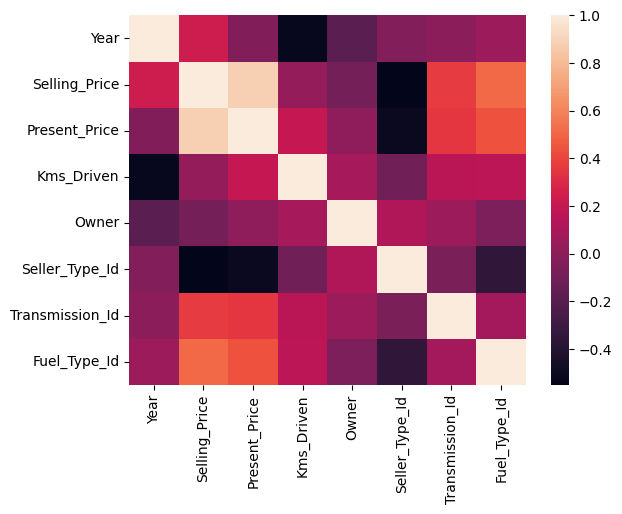

In [46]:
sns.heatmap(df_1.corr())
plt.show()

In [47]:
X=df_1.drop("Selling_Price",axis=1)
y=df_1["Selling_Price"]

In [48]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [49]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225 entries, 284 to 245
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             225 non-null    int64  
 1   Present_Price    225 non-null    float64
 2   Kms_Driven       225 non-null    int64  
 3   Owner            225 non-null    int64  
 4   Seller_Type_Id   225 non-null    int64  
 5   Transmission_Id  225 non-null    int64  
 6   Fuel_Type_Id     225 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 14.1 KB


In [50]:
X_train.corr()

,Year,Present_Price,Kms_Driven,Owner,Seller_Type_Id,Transmission_Id,Fuel_Type_Id
Year,1.000000,-0.062835,-0.511357,-0.221337,-0.047614,-0.006799,0.048344
Present_Price,-0.062835,1.000000,0.174858,0.048545,-0.470227,0.329063,0.395163
Kms_Driven,-0.511357,0.174858,1.000000,0.117790,-0.058253,0.178064,0.146817
Owner,-0.221337,0.048545,0.117790,1.000000,0.103669,0.095678,-0.037208
Seller_Type_Id,-0.047614,-0.470227,-0.058253,0.103669,1.000000,-0.060641,-0.342643
Transmission_Id,-0.006799,0.329063,0.178064,0.095678,-0.060641,1.000000,0.055829
Fuel_Type_Id,0.048344,0.395163,0.146817,-0.037208,-0.342643,0.055829,1.000000


In [51]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [52]:
corr_features=correlation(X_train,0.85)

In [53]:
corr_features

set()

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
scaler=StandardScaler()

In [56]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

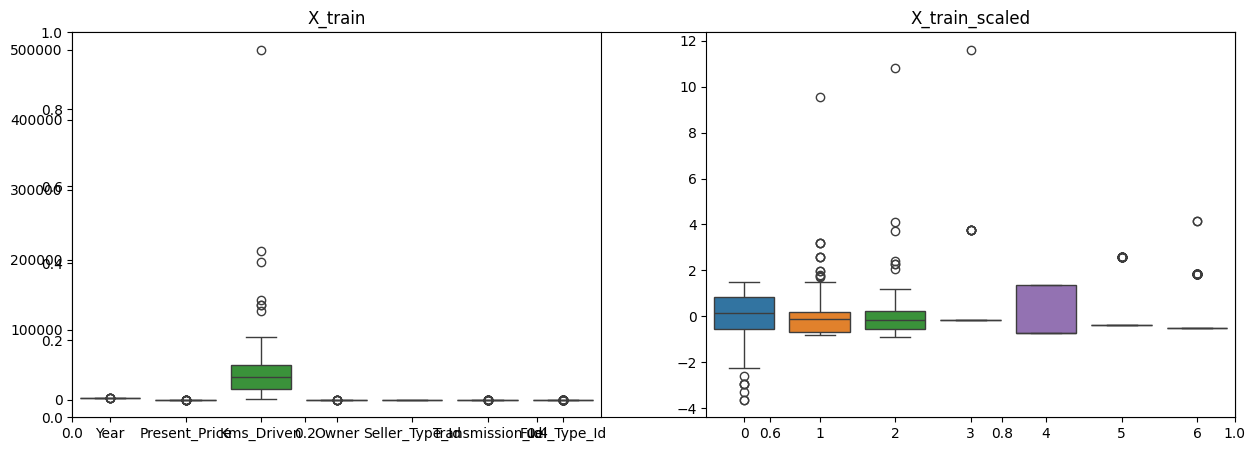

In [59]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train_scaled")
plt.show()

In [57]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mean_absolute_error: 1.3870495413518404
mean_squared_error: 5.230678405189675
R2 score: 0.8319269402410707


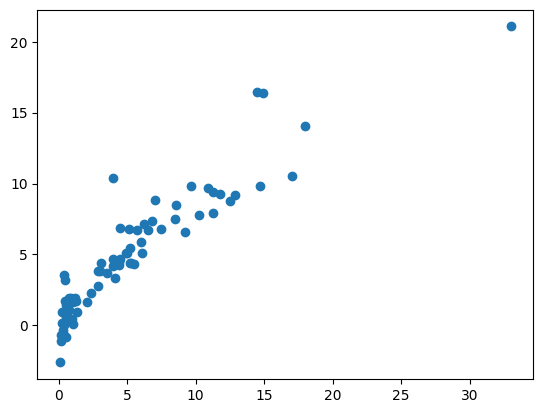

In [58]:
linear=LinearRegression()
linear.fit(X_train_scaled,y_train)
y_pred=linear.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error:",mae)
print("mean_squared_error:", mse)
print("R2 score:",score)
plt.scatter(y_test,y_pred)
plt.show()


mean_absolute_error: 2.072549405212923
mean_squared_error: 10.468143333735455
R2 score: 0.6636358147443483


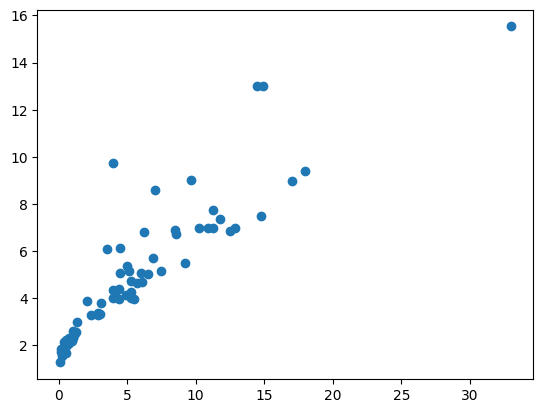

In [60]:
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error:",mae)
print("mean_squared_error:", mse)
print("R2 score:",score)
plt.scatter(y_test,y_pred)
plt.show()


mean_absolute_error: 1.3874834161563012
mean_squared_error: 5.258581085467202
R2 score: 0.8310303665107748


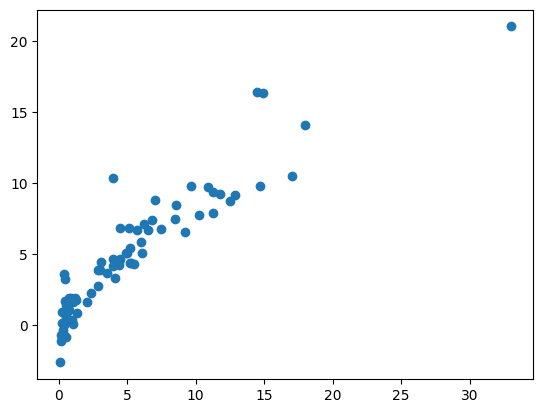

In [61]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error:",mae)
print("mean_squared_error:", mse)
print("R2 score:",score)
plt.scatter(y_test,y_pred)
plt.show()


mean_absolute_error: 1.9922966392672656
mean_squared_error: 10.785919721208487
R2 score: 0.6534249691093461


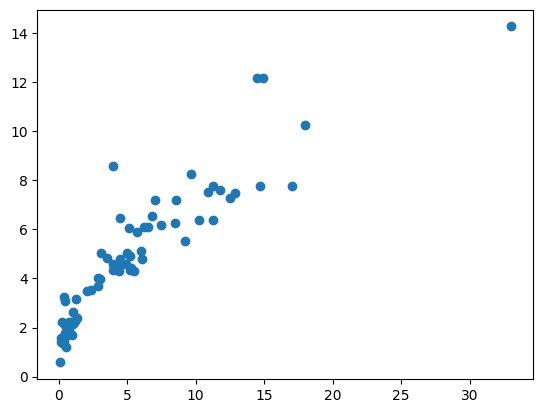

In [62]:
from sklearn.linear_model import ElasticNet
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error:",mae)
print("mean_squared_error:", mse)
print("R2 score:",score)
plt.scatter(y_test,y_pred)
plt.show()


mean_absolute_error: 0.7014515078896051
mean_squared_error: 1.0657224848866051
R2 score: 0.9657560214921518


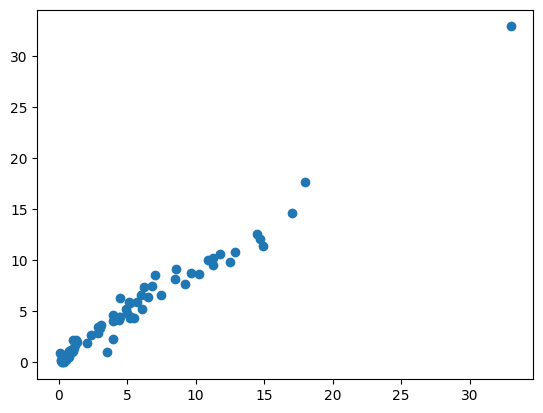

In [63]:
##Polinom Regresyon
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
linear=LinearRegression()
linear.fit(X_train_poly,y_train)
y_pred=linear.predict(X_test_poly)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error:",mae)
print("mean_squared_error:", mse)
print("R2 score:",score)
plt.scatter(y_test,y_pred)
plt.show()


In [64]:
linear.intercept_

np.float64(46040.83833056744)

mean_absolute_error: 1.3543277437381236
mean_squared_error: 5.580815125244826
R2 score: 0.8206762868238701


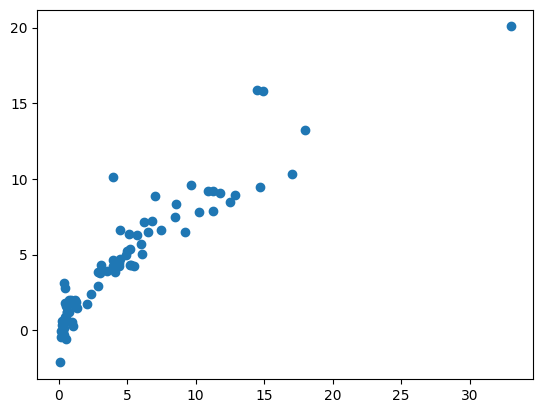

In [65]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV()
lassocv.fit(X_train_scaled,y_train)
y_pred=lassocv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean_absolute_error:",mae)
print("mean_squared_error:", mse)
print("R2 score:",score)
plt.scatter(y_test,y_pred)
plt.show()